# QeMCMC MIS: build model, set backend, and run MCMC optimize

This notebook / script:
- loads a DIMACS "edge" graph,
- builds the MIS EnergyModel,
- selects a backend via Qiskit Runtime Service and creates a preset pass manager,
- runs mcmc_optimize using SamplerV2,
- shows the energy history.

In [1]:
from qemcmc import load_dimacs_edge, mis_energy_model, random_bitstring, mcmc_optimize
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit.transpiler import generate_preset_pass_manager

## Load a graph and build the MIS model
Choose a graph filename available in qemcmc assets (or set QEMCMC_GRAPHS_DIR).

In [2]:
graph_file = "aves-sparrow-social.gph"
print(f"Loading graph {graph_file}")
g = load_dimacs_edge(graph_file)
print(f"nodes {g.num_nodes()}, edges {g.num_edges()}")

lam = 2.0
model, _ = mis_energy_model(g, lam=lam)
print("n_spins", model.n_spins)

Loading graph aves-sparrow-social.gph
nodes 52, edges 454
n_spins 52


## Choose initial state
Use a reproducible random bitstring as the starting configuration.

In [3]:
seed = 789
init_s = random_bitstring(model.n_spins, rng=seed)
print("initial bitstring:", init_s, "E0=", model.energy(init_s))

initial bitstring: 1000111000010000010011111101100110011111100001100001 E0= -26.0


## Backend and pass manager
Initialize Qiskit Runtime Service, pick a backend, and create a preset pass manager.
Uncomment Fake backend to run locally without an account.

In [4]:
service = QiskitRuntimeService()
backend = service.least_busy(min_num_qubits=model.n_spins)
# from qiskit_ibm_runtime.fake_provider import FakeFez
# backend = FakeFez()
print("backend:", backend)

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
sampler = SamplerV2(backend)

backend: <IBMBackend('ibm_fez')>


## Run MCMC optimization
Configure proposal evolution and Metropolis settings, then run the loop.

In [5]:
shots = 1
params = dict(gamma=0.5, time=6, delta_time=0.8, beta=1.0, patience=5, max_iters=200)
print("start:", init_s, "E=", model.energy(init_s))

start: 1000111000010000010011111101100110011111100001100001 E= -26.0


## Run the optimization loop

In [6]:
res = mcmc_optimize(
    init_s,
    model,
    pm,
    sampler,
    shots,
    gamma=params["gamma"],
    time=params["time"],
    delta_time=params["delta_time"],
    beta=params["beta"],
    patience=params["patience"],
    max_iters=params["max_iters"],
    rng=seed,
    log_every=1,
)

1 0000010000001000010000010001010011110011001010101001 -156.0
2 0001000000011001100010000000101000000001001011001010 -157.0
3 0000011000000100100100000011100010001001011001010000 -172.0
4 0000011000000100100100000011100010001001011001010000 -172.0
5 0000011000000100100100000011100010001001011001010000 -172.0
6 0000011000000100100100000011100010001001011001010000 -172.0
7 0100111000010000000000010101000001000000010000001111 -171.0
8 0100111000010000000000010101000001000000010000001111 -171.0


In [7]:
print("best_s:", res["best_s"], "best_E:", res["best_E"])
print("iters:", res["iters"], "accept_rate:", f'{res["accept_rate"]:.3f}')

best_s: 0000011000000100100100000011100010001001011001010000 best_E: -172.0
iters: 8 accept_rate: 0.500


## Plot energy history

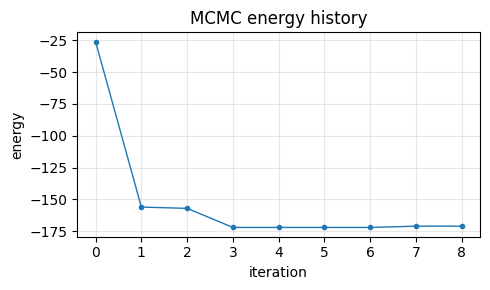

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 3))
plt.plot(res["history_E"], marker="o", ms=3, lw=1)
plt.xlabel("iteration")
plt.ylabel("energy")
plt.title("MCMC energy history")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("mcmc_energy_history.png")
# plt.show()